# Installation

In [1]:
!pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
# Modules
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import importlib

# Fonctions
from download_data import download_all
from data_vis import( 
    plot_returns_separately, 
    plot_gold_price_actual_vs_predicted_test, 
    plot_gold_var_residuals,
    plot_gold_var_squared_residuals,
    plot_gold_var_squared_residuals_acf,
    plot_gold_daily,
    load_and_merge_data,  
    plot_timeseries_multi,
    plot_correlation_heatmap,
    plot_geopolitical_timeline,
    plot_normalized_evolution,
    plot_scatter_matrix,
    plot_return_distributions,
    plot_gold_price_monte_carlo_test
)
from time_series_tests import adf_test_all_var_series, print_var_stability_conclusion, print_residual_serial_correlation_conclusion, get_granger_test_summary, granger_tests_for_gold, print_arch_lm_conclusion
from modele import (
    get_var_model_info,
    get_var_summary,
    run_full_var_train_test_pipeline,
    run_reduced_var_train_test_pipeline,
    print_final_lag_selection,
    extract_gold_var_residuals,
    build_dynamic_price_forecast,
    build_garch_forecast_df,
    build_garchx_forecast_df,
    reconstruct_price_path_from_returns,
    build_garchx_train_dataset,
    fit_garch11_student,
    fit_garch11x_student,
    get_garch_model_info,
    run_var_garchx_monte_carlo_pipeline

   
)
from preprocessing import prepare_var_dataset, load_market_data, clean_all_market_data, prepare_daily_macro_exog, split_macro_exog_train_test_by_date
import reduced_var_garch_monte_carlo as rgmc
import monte_carlo_vis as mcvis

/Users/adrienferrand-bastet/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


<module 'monte_carlo_vis' from '/Users/adrienferrand-bastet/Desktop/PRD/Data_python/monte_carlo_vis.py'>

# Import des données

In [3]:
download_all()

  Téléchargement des données
  Période : 2005-01-01 → 2026-04-21

── 1/3  Yahoo Finance ──────────────────────────────
  [gold] Téléchargement Yahoo Finance (GC=F)...
  [gold] ✓ 5352 observations → data/gold.csv
  [dxy] Téléchargement Yahoo Finance (DX-Y.NYB)...
  [dxy] ✓ 5363 observations → data/dxy.csv
  [sp500] Téléchargement Yahoo Finance (^GSPC)...
  [sp500] ✓ 5357 observations → data/sp500.csv
  [vix] Téléchargement Yahoo Finance (^VIX)...
  [vix] ✓ 5357 observations → data/vix.csv

── 2/3  FRED — CPI ─────────────────────────────────
  [cpi] Téléchargement FRED (série CPIAUCSL)...
  [cpi] ✓ 254 observations → data/cpi.csv

── 3/3  GPR — Iacoviello ───────────────────────────
  [gpr] Scraping de la page Iacoviello...
  [gpr] Fichier détecté : https://www.matteoiacoviello.com/gpr_files/data_gpr_export.xls
  [gpr] ✓ Fichier brut sauvegardé → data/gpr_raw.xls

  ✓ Tous les fichiers sont dans le dossier data/


### Chargement des données brutes

Dans cette étape, nous chargeons les séries financières qui seront utilisées pour la modélisation et la prédiction du prix de l’or.
Les fichiers ont été préalablement téléchargés depuis Yahoo Finance et sont importés sous forme brute afin d’être nettoyés par la suite.

Les séries utilisées sont les suivantes :

**gold : prix de l’or**
- Il s’agit de la variable cible du projet, que l’on cherche à modéliser et à prédire.

**dxy : US Dollar Index**
- Mesure la valeur du dollar américain et il est généralement inversement corrélé au prix de l’or.

**sp500 : indice S&P 500 index**
- Représente la performance du marché actions américain.

**vix : indice CBOE Volatility Index (VIX)**
- Mesure la volatilité attendue des marchés financiers.
- Une hausse du VIX est souvent associée à une augmentation de la demande d’or

**cpi : inflation**
- Indicateur macroéconomique influençant les politiques monétaires.

**gpr : indice de risque géopolitique**
- Capture les tensions géopolitiques globales.

In [4]:
raw_data = load_market_data(data_dir="data")
raw_data['gold']

,0,1,2,3,4,5,6
0,Price,Adj Close,Close,High,Low,Open,Volume
1,Ticker,GC=F,GC=F,GC=F,GC=F,GC=F,GC=F
2,Date,NaN,NaN,NaN,NaN,NaN,NaN
3,2005-01-03,428.70001220703125,428.70001220703125,431.0,431.0,431.0,4
4,2005-01-04,428.5,428.5,428.5,428.5,428.5,108
...,...,...,...,...,...,...,...
5350,2026-04-14,4825.0,4825.0,4841.60009765625,4770.10009765625,4770.10009765625,288
5351,2026-04-15,4800.0,4800.0,4843.60009765625,4798.0,4843.60009765625,182
5352,2026-04-16,4785.39990234375,4785.39990234375,4810.89990234375,4785.39990234375,4810.89990234375,805
5353,2026-04-17,4857.60009765625,4857.60009765625,4879.7001953125,4767.2001953125,4771.60009765625,1902


Les autres variables présentent la même structure.  
Il est donc nécessaire de restructurer les en-têtes afin de ne conserver que les colonnes pertinentes et d’obtenir un format de données exploitable.

- **Close (prix de clôture) :** dernier prix auquel l’or a été échangé à la fin de la journée.
- **Adj Close (Adjusted Close) :** prix de clôture ajusté pour tenir compte d’événements financiers (dividendes, splits).
- **Open (prix d’ouverture) :** prix du premier échange au début de la journée.
- **High (prix maximum) :** prix le plus élevé atteint durant la journée.
- **Low (prix minimum) :** prix le plus bas atteint durant la journée.
- **Volume :** nombre de contrats échangés au cours de la journée. Il reflète le niveau d’activité du marché.

In [5]:
# Chargement & fusion
df = load_and_merge_data()
df.tail(3)

Chargement des données...
GPR chargé depuis l'onglet 'Sheet1' (495 obs)
DataFrame fusionné : 254 observations, 6 variables
Période : 2005-01-31 → 2026-03-31


,gold,dxy,sp500,vix,cpi,gpr
date,,,,,,
2026-01-31,4730.859961,98.208999,6929.121973,16.046000,326.588,167.800201
2026-02-28,5011.036827,97.455263,6893.806281,19.239474,327.460,121.616882
2026-03-31,4856.390891,99.482273,6654.419123,25.596818,330.293,297.269806


# Préprocessing 

Afin de préparer les données pour la modélisation, un pipeline complet de prétraitement a été implémenté. Celui-ci est encapsulé dans la fonction `prepare_var_dataset`.

Ce pipeline suit les étapes suivantes :

1. **Chargement des données**  
   Les séries financières (or, dollar, S&P500, VIX) sont importées depuis des fichiers CSV.

2. **Nettoyage des données**  
   Les fichiers issus de Yahoo Finance contiennent des lignes d’en-tête parasites.  
   Ces lignes sont supprimées et les colonnes sont restructurées afin d’obtenir un format standard avec :
   - une colonne de date
   - une colonne de prix

3. **Transformation en rendements**  
   Les prix sont transformés en rendements logarithmiques afin d’obtenir des séries stationnaires, adaptées à la modélisation.

4. **Fusion des séries**  
   Les différentes séries sont fusionnées sur la variable temporelle (date) afin d’obtenir un jeu de données cohérent.

5. **Suppression des valeurs manquantes**  
   Les observations incomplètes, notamment dues au calcul des rendements, sont supprimées.

Le résultat est un dataset final contenant les rendements des différentes variables, prêt à être utilisé dans un modèle VAR.

In [6]:
var_df = prepare_var_dataset(data_dir="data")
var_df

,date,gold_ret,dxy_ret,sp500_ret,vix_ret
0,2005-01-04,-0.000467,0.015500,-0.011740,-0.007128
1,2005-01-05,-0.004444,-0.000363,-0.003634,0.007838
2,2005-01-06,-0.013214,0.007363,0.003500,-0.036867
3,2005-01-07,-0.005001,0.005517,-0.001432,-0.006649
4,2005-01-10,0.000477,-0.003835,0.003417,-0.019462
...,...,...,...,...,...
5342,2026-04-14,0.017267,-0.002545,0.011714,-0.040561
5343,2026-04-15,-0.005195,-0.000612,0.007944,-0.010403
5344,2026-04-16,-0.003046,0.001630,0.002607,-0.012739
5345,2026-04-17,0.014975,-0.001223,0.011969,-0.025976


# Visualisation

In [7]:
# 0 — Or quotidien brut (candlestick + MM50/200 + volume)
plot_gold_daily()

[Plotly] Or quotidien → figures/gold_daily.html


Ce graphique présente l'intégralité des données quotidiennes du prix de l'or sur la période 2005–présent, accompagnées des moyennes mobiles à 50 et 200 jours ainsi que du volume d'échanges. On distingue trois phases distinctes. Une première phase haussière de 2005 à 2011 porte le prix de ~$450 à ~$1900, portée par la crise financière de 2008 et la demande de valeurs refuges. S'ensuit une décennie de consolidation (2012–2018) où le prix oscille entre $1100 et $1400, les deux moyennes mobiles évoluant à plat et souvent entrelacées — signal d'absence de tendance directrice. La troisième phase, amorcée en 2019 et accélérée post-COVID, marque une rupture structurelle nette : le prix franchit ses plus hauts historiques successifs pour atteindre $5000 en 2025, avec les MM50 et MM200 toutes deux orientées à la hausse et bien espacées, caractéristique d'une tendance haussière forte. Le volume, relativement stable sur la majeure partie de la période, présente un pic visible en 2025 coïncidant avec l'accélération des prix, suggérant une augmentation de l'activité spéculative en plus de la demande refuge.

In [8]:
# 1 — Séries temporelles (6 panneaux, base 100)
plot_timeseries_multi(df)

[Plotly] Séries temporelles → figures/timeseries_multi.html


Les six variables sont normalisées en base 100 à janvier 2005 afin de rendre leurs dynamiques comparables. On observe que l'or et le S&P 500 affichent les progressions les plus marquées sur la période tandis que le VIX et le GPR se distinguent par leurs pics ponctuels coïncidant avec les grands chocs — crise de 2008, COVID-19 et invasion de l'Ukraine. Le CPI amorce une accélération visible à partir de 2021, et le DXY reste le plus stable des six. Ces co-mouvements constituent une première motivation visuelle pour l'approche VAR.

In [9]:
# 3.2 — Heatmap des corrélations (niveaux + différences premières)
plot_correlation_heatmap(df)

[Plotly] Heatmap corrélations → figures/correlation_heatmap.html


La heatmap présente les corrélations de Pearson entre les six variables, en niveaux (gauche) et en différences premières (droite). La distinction est importante : les séries en niveaux sont non-stationnaires, ce qui gonfle artificiellement les corrélations ; les différences premières reflètent les vraies co-variations à court terme et sont utilisées dans l'estimation du modèle VAR. En niveaux, l'or affiche de fortes corrélations positives avec le CPI (0.86), le S&P 500 (0.85) et le DXY (0.47), traduisant des tendances communes sur le long terme plutôt que des relations causales directes. En différences premières en revanche, ces corrélations s'effondrent quasi toutes vers zéro — à l'exception notable de la relation VIX / S&P 500 (-0.67), attendue, et DXY / Or (-0.33), cohérente avec la relation inverse bien documentée entre le dollar et l'or.

In [10]:
# 3.3 — Timeline géopolitique (or + GPR + événements annotés)
plot_geopolitical_timeline(df)

[Plotly] Timeline géopolitique → figures/geopolitical_timeline.html


Ce graphique superpose le prix de l'or (ligne, axe gauche) et l'indice GPR (aire, axe droit) sur la période 2005–2025, avec les principaux chocs annotés. Plusieurs épisodes illustrent la réactivité de l'or aux tensions géopolitiques : la faillite Lehman Brothers (2008) et la crise de la dette européenne (2010) coïncident avec un premier cycle haussier atteignant un pic à $1900 en 2011. L'invasion de l'Ukraine (2022) et le conflit Gaza (2023) s'accompagnent d'une reprise marquée, culminant avec un nouvel ATH au-dessus de $2300 en 2024, puis une accélération spectaculaire vers $5000 en 2025.
Le GPR, en revanche, présente des pics ponctuels et réversibles qui ne se traduisent pas systématiquement par une hausse durable de l'or — suggérant que le risque géopolitique agit davantage comme catalyseur à court terme que comme déterminant structurel du prix. C'est précisément cette relation dynamique que le modèle VAR cherche à quantifier.

In [11]:
# 3.4 — Évolution normalisée sur un seul graphique (style cluster lines)
plot_normalized_evolution(df)

[Plotly] Évolution normalisée → figures/normalized_evolution.html


Ce graphique superpose les six variables sur un même axe en base 100, permettant une lecture directe des performances relatives sur vingt ans. Le classement final en 2025 est sans appel : l'or domine largement avec un indice à 1102, soit une multiplication par plus de 11, devant le S&P 500 (553) et le GPR (295). À l'opposé, le DXY (120), le CPI (165) et le VIX gravitent autour de leurs niveaux initiaux, confirmant qu'ils n'ont pas de tendance haussière structurelle sur la période. Le VIX se distingue néanmoins par ses pics de volatilité extrêmes en 2008 et 2020, visibles comme des sursauts brefs avant un retour rapide à la moyenne — comportement typique d'une série mean-reverting. La divergence croissante entre l'or et les autres variables à partir de 2022 constitue le signal le plus saillant du graphique, et pose directement la question centrale du projet : quels facteurs expliquent et permettent de prédire cette trajectoire exceptionnelle ?

In [12]:
# 3.5 — Scatter matrix complète (pairplot coloré par niveau de l'or)
plot_scatter_matrix(df)

[Plotly] Scatter matrix → figures/scatter_matrix.html


La scatter matrix présente toutes les relations bivariées entre les six variables, avec chaque point coloré selon le niveau du prix de l'or (bleu = bas, rouge = haut). La couleur ajoute une dimension temporelle implicite : les points rouges/oranges correspondent aux périodes récentes où l'or est élevé. Plusieurs relations ressortent. Or / CPI et Or / S&P 500 affichent des nuages allongés et progressivement colorés du bleu au rouge, traduisant des tendancescommunes de long terme déjà identifiées dans la heatmap. La relation Or / DXY montre un nuage plus dispersé avec une légère pente négative, cohérente avec la relation inverse attendue entre le dollar et l'or. Le VIX se distingue par son comportement atypique : ses nuages avec toutes les autres variables forment des masses compactes à faibles valeurs parsemées de points extrêmes isolés, confirmant sa nature de variable à distribution très asymétrique. Enfin, le GPR présente des nuages quasi-circulaires avec la plupart des variables, suggérant une faible relation linéaire en niveaux — ce que les différences premières de la heatmap avaient déjà confirmé.

In [13]:
raw_data = load_market_data()
cleaned_data = clean_all_market_data(raw_data)
cleaned_data.keys()
gold = cleaned_data["gold"]
dxy = cleaned_data["dxy"]
sp500 = cleaned_data["sp500"]
vix = cleaned_data["vix"]
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
price_df = gold.merge(dxy, on="date", how="inner") \
         .merge(sp500, on="date", how="inner") \
         .merge(vix, on="date", how="inner")

price_df = df.sort_values("date")

In [14]:
'''for col in ["gold_price", "sp500_price", "dxy_price", "vix_price"]:
    df_norm[col] = df_norm[col] / df_norm[col].iloc[0] * 100

plt.figure()
sns.lineplot(data=df_norm, x="date", y="gold_price", label="Gold")
sns.lineplot(data=df_norm, x="date", y="sp500_price", label="SP500")
sns.lineplot(data=df_norm, x="date", y="dxy_price", label="DXY")
sns.lineplot(data=df_norm, x="date", y="vix_price", label="VIX")
plt.title("Comparaison des actifs (base 100)")
plt.ylabel("Base 100")
plt.show()
# J'ai fais une fonctions qui fais ça : plot_all_prices()'''


'for col in ["gold_price", "sp500_price", "dxy_price", "vix_price"]:\n    df_norm[col] = df_norm[col] / df_norm[col].iloc[0] * 100\n\nplt.figure()\nsns.lineplot(data=df_norm, x="date", y="gold_price", label="Gold")\nsns.lineplot(data=df_norm, x="date", y="sp500_price", label="SP500")\nsns.lineplot(data=df_norm, x="date", y="dxy_price", label="DXY")\nsns.lineplot(data=df_norm, x="date", y="vix_price", label="VIX")\nplt.title("Comparaison des actifs (base 100)")\nplt.ylabel("Base 100")\nplt.show()\n# J\'ai fais une fonctions qui fais ça : plot_all_prices()'

In [15]:
'''plt.figure()
sns.lineplot(data=df_norm, x="date", y="gold_price", label="Gold")
sns.lineplot(data=df_norm, x="date", y="vix_price", label="VIX")
plt.title("Or vs VIX (actif refuge ?)")
plt.show()'''


'plt.figure()\nsns.lineplot(data=df_norm, x="date", y="gold_price", label="Gold")\nsns.lineplot(data=df_norm, x="date", y="vix_price", label="VIX")\nplt.title("Or vs VIX (actif refuge ?)")\nplt.show()'

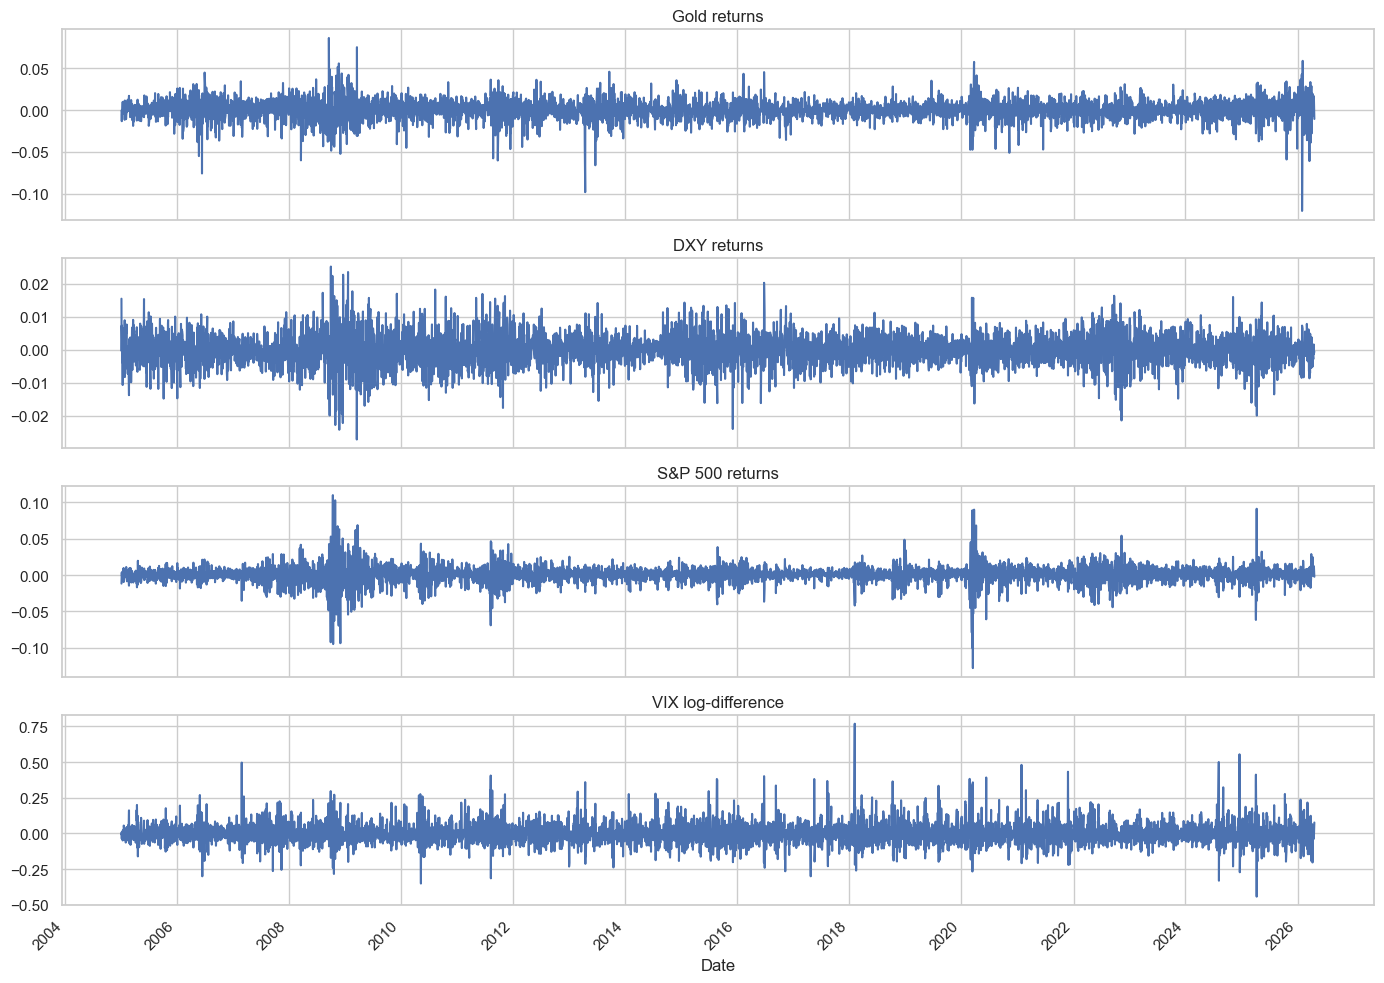

In [16]:
plot_returns_separately(var_df)

# Distribution des rendements - Tests de normalité 

Nous analysons la distribution des rendements logarithmiques des différentes séries financières afin de vérifier certaines hypothèses statistiques clés avant la modélisation. 
L’objectif est de comparer la distribution empirique des rendements à une distribution normale, à l’aide :
- d’un histogramme
- d’une densité empirique (KDE)
- d’une loi normale théorique
 des moments statistiques (skewness, kurtosis)
- du test de normalité de Jarque-Bera


### Skewness (asymétrie)

La skewness mesure le degré d’asymétrie d’une distribution autour de sa moyenne. 

Elle permet d’identifier si les valeurs extrêmes se situent davantage à gauche ou à droite de la distribution.

### Définition formelle

Pour une variable aléatoire X, la skewness est définie par :
$
\text{Skewness}(X) = \frac{\mathbb{E}[(X - \mu)^3]}{\sigma^3}
$

Dans le cas d’un échantillon de taille n:
$
\widehat{\text{Skewness}} = \frac{1}{n} \sum_{i=1}^{n} \left(\frac{x_i - \bar{x}}{s}\right)^3
$


### Interprétation

- Skewness = 0 : distribution symétrique (proche d’une loi normale)
- Skewness < 0 : asymétrie à gauche, indiquant des valeurs extrêmes négatives plus fréquentes
- Skewness > 0 : asymétrie à droite, indiquant des valeurs extrêmes positives plus fréquentes

---

### Kurtosis (aplatissement / queues de distribution)

La kurtosis mesure l’épaisseur des queues d’une distribution, c’est-à-dire la fréquence des événements extrêmes par rapport à une distribution normale.

### Définition formelle

Pour une variable aléatoire :
$
\text{Kurtosis}(X) = \frac{\mathbb{E}[(X - \mu)^4]}{\sigma^4}
$

Pour un échantillon :
$
\widehat{\text{Kurtosis}} = \frac{1}{n} \sum_{i=1}^{n} \left(\frac{x_i - \bar{x}}{s}\right)^4
$

### Interprétation

- Kurtosis ≈ 0 (excès) : distribution proche de la normale
- Kurtosis > 0 : queues épaisses (fat tails), présence fréquente d’événements extrêmes
- Kurtosis < 0 : queues fines, distribution plus plate et moins d’extrêmes

---

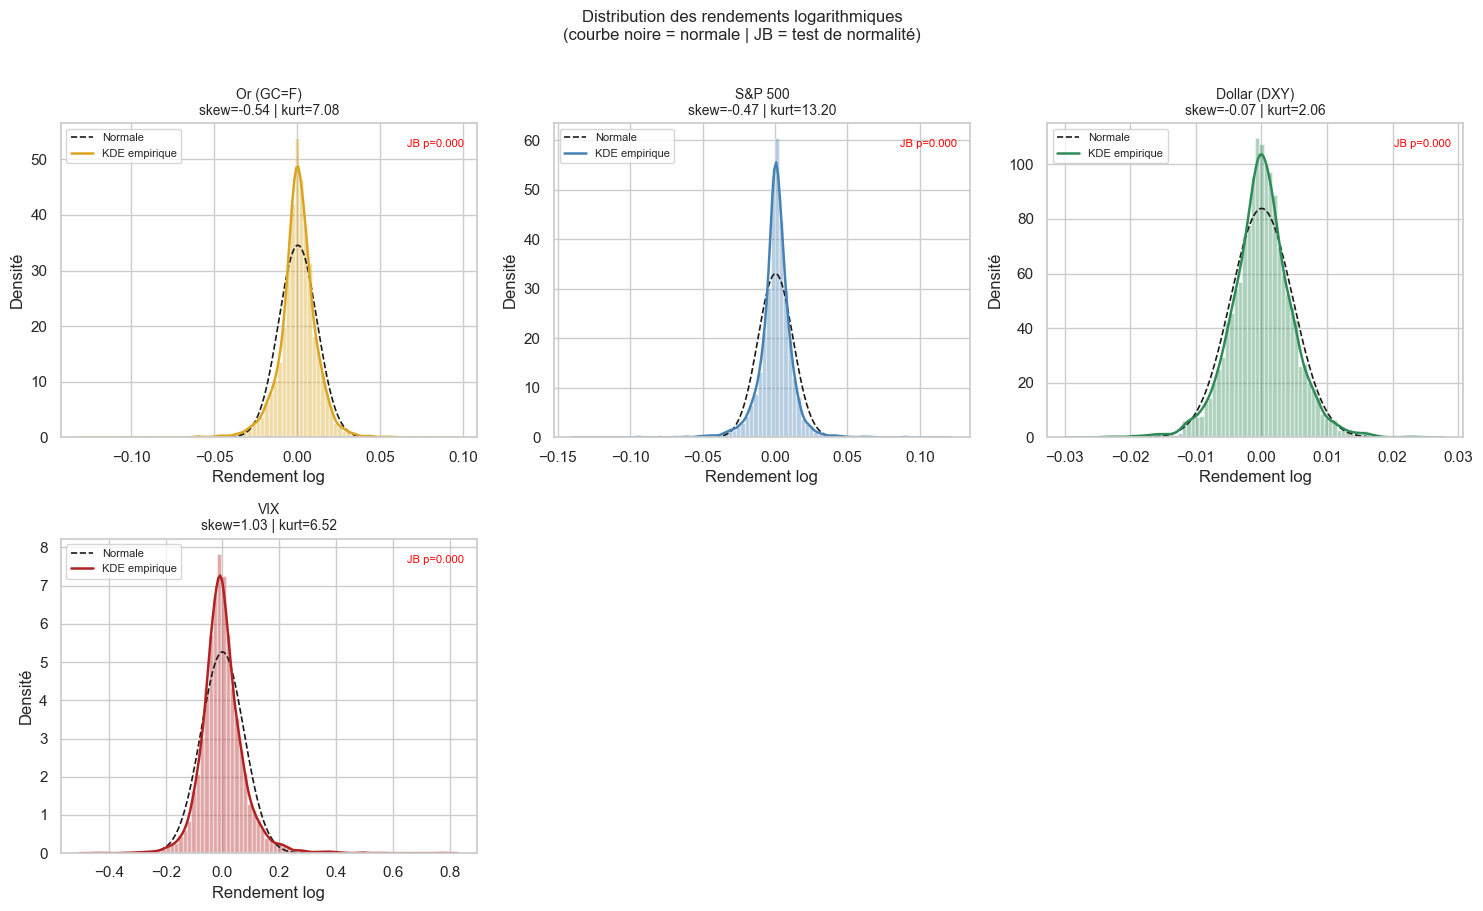

In [17]:
plot_return_distributions(var_df)

### Interprétation 
Pour toutes les séries, la p-value du test JB est 0.000. Donc, on rejette la normalité

Conclusion: les rendements financiers ne suivent pas une loi normale.

**kurtosis**
- Gold :  = 7.08
- S&P 500 : 13.19 
- VIX : 6.52
- DXY : 2.06 (moins extrême)

Toutes les séries ont des valeurs > 0, ce qui implique la présence de queues épaisses.

**Skewness**
- Gold : légèrement négative
- S&P 500 < 0 : asymétrie négative
- VIX > 0 : asymétrie positive
- DXY proche de 0 : distribution relativement symétrique


Les modèles de type Vector Autoregression (VAR) reposent généralement sur des hypothèses implicites de normalité des résidus. Or, la présence de skewness non nulle et de kurtosis élevée dans les données financières indiquent la présence de chocs importants et une déviation significative par rapport à la normalité impliquant une sous-estimation des événements extrêmes et une limitation dans la modélisation des chocs de marché.

# TEST sur les séries

Test ADF qui vérifie la stationarité des séries (returns)

In [18]:
adf_results = adf_test_all_var_series(var_df)
adf_results 

,series,adf_statistic,p_value,used_lags,n_obs,critical_value_1pct,critical_value_5pct,critical_value_10pct,stationary_5pct
0,gold_ret,-29.202517,0.000000e+00,6,5340,-3.431575,-2.862081,-2.567058,True
1,dxy_ret,-22.028584,0.000000e+00,10,5336,-3.431576,-2.862082,-2.567058,True
2,sp500_ret,-16.354459,2.910981e-29,19,5327,-3.431578,-2.862083,-2.567059,True
3,vix_ret,-29.438877,0.000000e+00,8,5338,-3.431576,-2.862082,-2.567058,True


On a donc des p-value > 0.05 donc l'ensemble des séries sont stationaires 

# VAR

## Modélisation 

Ici, on commence par reconstruire un **DataFrame de prix bruts** à partir des séries nettoyées de l’or, du DXY, du S&P 500 et du VIX. Ces séries sont fusionnées sur la date afin d’obtenir un calendrier commun, ce qui permet ensuite de reconstruire correctement les prix prévus de l’or sur la période de test.

Ensuite, `run_full_var_train_test_pipeline(...)` exécute le pipeline complet du **VAR avec S&P 500** :
- découpage train / test,
- sélection du lag optimal sur le train,
- estimation finale du VAR,
- prévision dynamique des rendements sur le test,
- reconstruction dynamique du prix de l’or à partir des rendements prévus.

Enfin, `plot_gold_price_actual_vs_predicted_test(...)` permet de comparer visuellement le **prix observé** et le **prix prédit** de l’or sur la période de test.


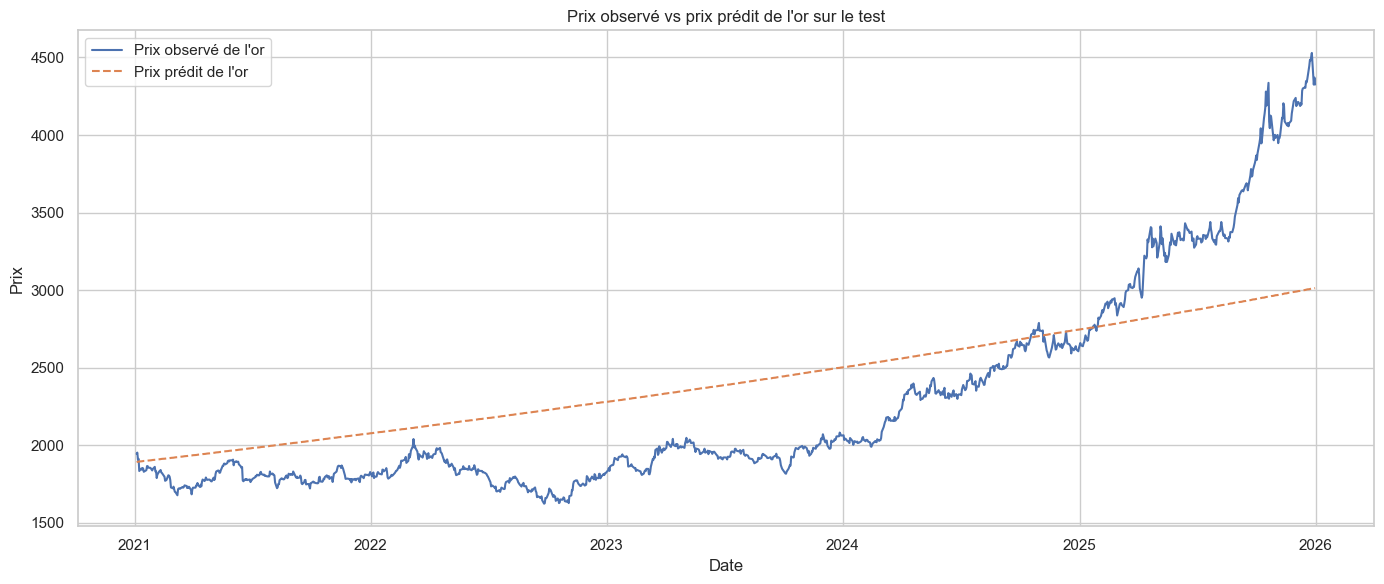

In [19]:
raw_data = load_market_data(data_dir="data")
cleaned_data = clean_all_market_data(raw_data)

gold = cleaned_data["gold"]
dxy = cleaned_data["dxy"]
sp500 = cleaned_data["sp500"]
vix = cleaned_data["vix"]

price_df = (
    gold.merge(dxy, on="date", how="inner")
        .merge(sp500, on="date", how="inner")
        .merge(vix, on="date", how="inner")
        .sort_values("date")
        .reset_index(drop=True)
)

full_var_results = run_full_var_train_test_pipeline(
    var_df=var_df,
    price_df=price_df,
    train_start="2005-01-01",
    train_end="2020-12-31",
    test_start="2021-01-01",
    test_end="2025-12-31",
    window_years=7,
    step_years=2,
    max_lag=10,
    price_reconstruction_mode="dynamic"
)
plot_gold_price_actual_vs_predicted_test(full_var_results["gold_price_forecast_df"])

J'ai ajouté un VAR sans le SP500 car plus tard dans les tests sur le VAR, on voit qu'il n'apporte pas de valeur prédicitive. 

Lags sélectionnés sur l'ensemble des fenêtres (AIC + BIC) :
[10, 10, 10, 1, 1, 1, 1, 1, 1, 1]

Moyenne des lags sélectionnés : 3.7000
Lag final retenu (arrondi) : 4
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 21, Apr, 2026
Time:                     19:43:02
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -24.8746
Nobs:                     4014.00    HQIC:                  -24.9141
Log likelihood:           32998.4    FPE:                1.48083e-11
AIC:                     -24.9358    Det(Omega_mle):     1.46653e-11
--------------------------------------------------------------------
Results for equation gold_ret
                 coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------
const               0.000381         0.000183            2

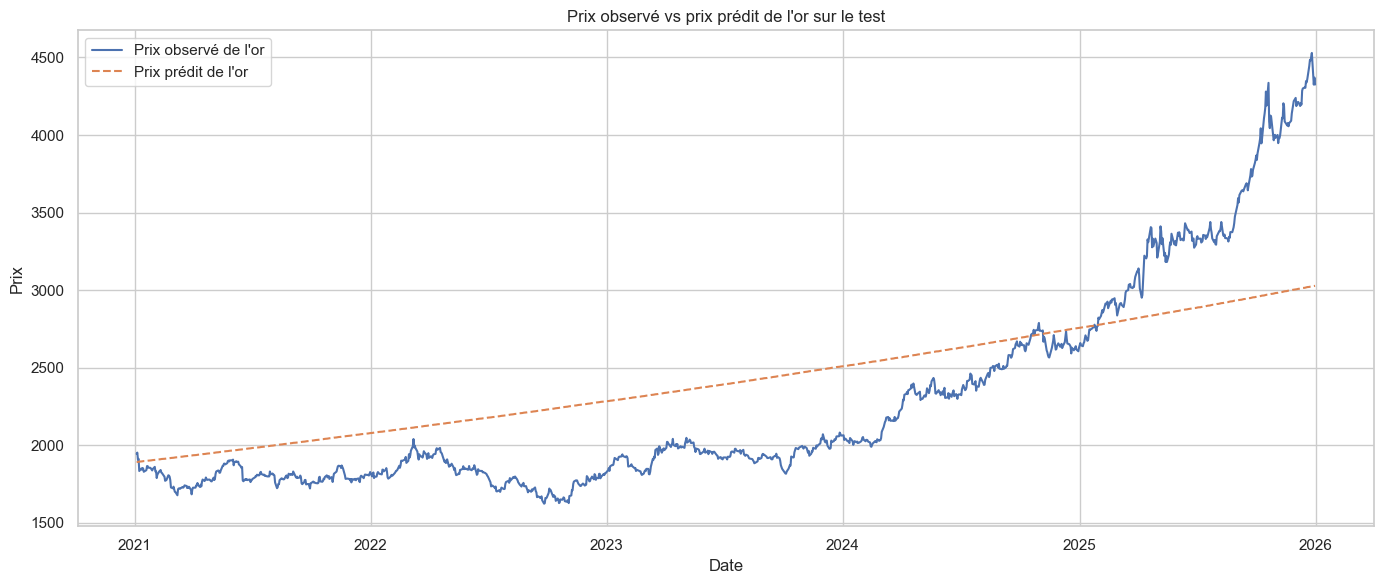

In [20]:
reduced_var_results = run_reduced_var_train_test_pipeline(
    var_df=var_df,
    price_df=price_df,
    train_start="2005-01-01",
    train_end="2020-12-31",
    test_start="2021-01-01",
    test_end="2025-12-31",
    window_years=7,
    step_years=2,
    max_lag=10
)
print_final_lag_selection(reduced_var_results["final_lag_dict"])
reduced_var_results["lag_summary_df"]
reduced_var_results["final_lag"]
print(get_var_summary(reduced_var_results["fitted_model"]))
get_var_model_info(reduced_var_results["fitted_model"])
reduced_var_results["gold_price_forecast_df"].head()
plot_gold_price_actual_vs_predicted_test(reduced_var_results["gold_price_forecast_df"])

La sélection du lag en rolling window donne des résultats assez hétérogènes : certaines fenêtres retiennent un lag élevé (`10`), tandis que la majorité sélectionne un lag faible (`1`). En moyenne, cela conduit à un **lag final de 4**, ce qui constitue un compromis raisonnable entre flexibilité dynamique et parcimonie.

Le modèle estimé est globalement bien ajusté, avec des critères d’information faibles (`AIC = -24.94`, `BIC = -24.87`) et un grand nombre d’observations (`4014`). Cela suggère que le VAR réduit offre une représentation correcte de la dynamique conjointe des trois séries retenues.

Dans l’équation de **l’or (`gold_ret`)**, les variables les plus informatives sont surtout les retards du **DXY** et du **VIX** au premier lag :
- `L1.dxy_ret` est significatif et négatif ;
- `L1.vix_ret` est significatif et négatif.

Cela signifie qu’à court terme, une hausse du dollar ou du VIX tend à être associée à une baisse du rendement de l’or dans cette spécification. En revanche, les propres retards de l’or apparaissent peu significatifs.

Dans l’équation du **DXY**, plusieurs retards sont significatifs, notamment certains retards de l’or et du VIX. Cela suggère une dynamique plus interdépendante, même si tous les coefficients ne sont pas significatifs.

Dans l’équation du **VIX**, ce sont surtout les retards du **VIX lui-même** qui ressortent nettement. Cela indique une forte inertie propre de cette variable, ce qui est cohérent avec la persistance souvent observée dans les épisodes de stress de marché.

Enfin, la matrice de corrélation des résidus montre une corrélation négative marquée entre **l’or** et le **DXY** (`-0.378`), ce qui est économiquement cohérent. En revanche, la corrélation entre l’or et le VIX est très faible dans les résidus, ce qui suggère qu’une grande partie de leur dépendance a déjà été absorbée par le modèle.

En résumé :
- le **lag 4** est un compromis issu d’une sélection de lag hétérogène ;
- le **DXY** et le **VIX** jouent un rôle important dans la prévision du rendement de l’or à court terme ;
- le **VIX** présente une forte dynamique autorégressive ;
- et la relation négative entre **or** et **dollar** apparaît clairement dans le système estimé.


In [21]:
full_var_results["gold_price_forecast_df"].head(20)

,date,gold_ret_pred,gold_ret_actual,gold_price_actual,gold_price_pred
0,2021-01-04,-0.000644,0.026892,1944.699951,1891.881334
1,2021-01-05,0.000748,0.004105,1952.699951,1893.297670
2,2021-01-06,0.000365,-0.023734,1906.900024,1893.989446
3,2021-01-07,0.000354,0.002828,1912.300049,1894.660725
4,2021-01-08,0.000373,-0.041753,1834.099976,1895.367000
5,2021-01-11,0.000371,0.008416,1849.599976,1896.071129
6,2021-01-12,0.000371,-0.003629,1842.900024,1896.773786
7,2021-01-13,0.000371,0.005789,1853.599976,1897.477190
8,2021-01-14,0.000371,-0.001782,1850.300049,1898.180829
9,2021-01-15,0.000371,-0.011414,1829.300049,1898.884708


On observe ici que les **rendements prédits deviennent quasiment constants** après les premiers jours de la période de test. Très vite, `gold_ret_pred` converge vers une valeur proche de `0.000371`, alors que les rendements observés restent, eux, très volatils et changent fortement d’un jour à l’autre.

Cette convergence vers une constante se répercute directement sur la reconstruction des prix : `gold_price_pred` évolue alors de manière très régulière, presque mécanique, tandis que `gold_price_actual` continue à fluctuer nettement. Autrement dit, le modèle ne parvient plus à reproduire la dynamique réelle du marché.

Cela confirme une limite importante du VAR dynamique : **comme le modèle est stable, les prévisions de rendements convergent progressivement vers leur moyenne de long terme**. À horizon un peu éloigné, les rendements prédits deviennent donc trop lisses, ce qui rend la trajectoire de prix prédite de plus en plus déconnectée de la réalité et donc rapidement obsolète.


## Test sur le VAR

TEST de la stabilité du VAR 

In [22]:
fitted_model = full_var_results["fitted_model"]
print_var_stability_conclusion(fitted_model)

Test de stabilité du VAR
------------------------
Le modèle est-il stable ? True
Conclusion : toutes les racines sont à l'extérieur du cercle unité.
Le VAR peut être considéré comme stable.


Le VAR est donc stable 

TEST d'autocorrélation des résidus 

In [23]:
print_residual_serial_correlation_conclusion(fitted_model, nlags=12)

Test d'autocorrélation des résidus (Portmanteau)
------------------------------------------------
Nombre de lags testés : 12
Statistique de test : 411.179842
Valeur critique : 190.516457
p-value : 0.000000
Degrés de liberté : 160
Conclusion : on rejette l'hypothèse nulle au seuil de 5%.
Les résidus présentent encore de l'autocorrélation.


Bien que le VAR(3) soit stable, le test de Portmanteau rejette nettement l’hypothèse d’absence d’autocorrélation résiduelle. Cela suggère que la structure dynamique du système n’est pas entièrement capturée par trois retards

TEST de causalité de granger 

In [24]:
granger_results = granger_tests_for_gold(fitted_model)
granger_results

,caused,causing,test_statistic,p_value,df,reject_h0_5pct
0,gold_ret,dxy_ret,9.748375,0.000059,"(2, 16028)",True
1,gold_ret,sp500_ret,1.301777,0.272077,"(2, 16028)",False
2,gold_ret,vix_ret,5.545596,0.003912,"(2, 16028)",True


Ainsi, à fréquence journalière, les variations du dollar et du stress de marché contiennent de l’information utile pour prévoir l’or, davantage que les rendements actions eux-mêmes.

Retrait du Sp500

In [25]:
fitted_model = reduced_var_results["fitted_model"]
print_var_stability_conclusion(fitted_model)

Test de stabilité du VAR
------------------------
Le modèle est-il stable ? True
Conclusion : toutes les racines sont à l'extérieur du cercle unité.
Le VAR peut être considéré comme stable.


In [26]:
print_residual_serial_correlation_conclusion(fitted_model, nlags=12)

Test d'autocorrélation des résidus (Portmanteau)
------------------------------------------------
Nombre de lags testés : 12
Statistique de test : 181.042928
Valeur critique : 92.808270
p-value : 0.000000
Degrés de liberté : 72
Conclusion : on rejette l'hypothèse nulle au seuil de 5%.
Les résidus présentent encore de l'autocorrélation.


In [27]:
granger_results_reduced = pd.DataFrame([
    get_granger_test_summary(fitted_model, caused="gold_ret", causing="dxy_ret"),
    get_granger_test_summary(fitted_model, caused="gold_ret", causing="vix_ret"),
])

granger_results_reduced

,caused,causing,test_statistic,p_value,df,reject_h0_5pct
0,gold_ret,dxy_ret,5.836291,0.000109,"(4, 12003)",True
1,gold_ret,vix_ret,3.422094,0.008383,"(4, 12003)",True


Le retrait du S&P 500 améliore la qualité du VAR et confirme que les déterminants les plus utiles pour l’or sont le dollar et le VIX. En revanche, le test de whiteness restant rejeté, le modèle à 3 variables ne constitue pas encore une spécification pleinement satisfaisante du point de vue dynamique.


# VAR-GARCH-X 

Au vu de nos résultats, un VAR-GARCH-X se justifie car le DXY et le VIX ont un pouvoir prédictif sur les rendements de l’or, tandis que la dynamique résiduelle restante suggère qu’il faut modéliser non seulement la moyenne conditionnelle, mais aussi la volatilité conditionnelle.

## Préprocessing

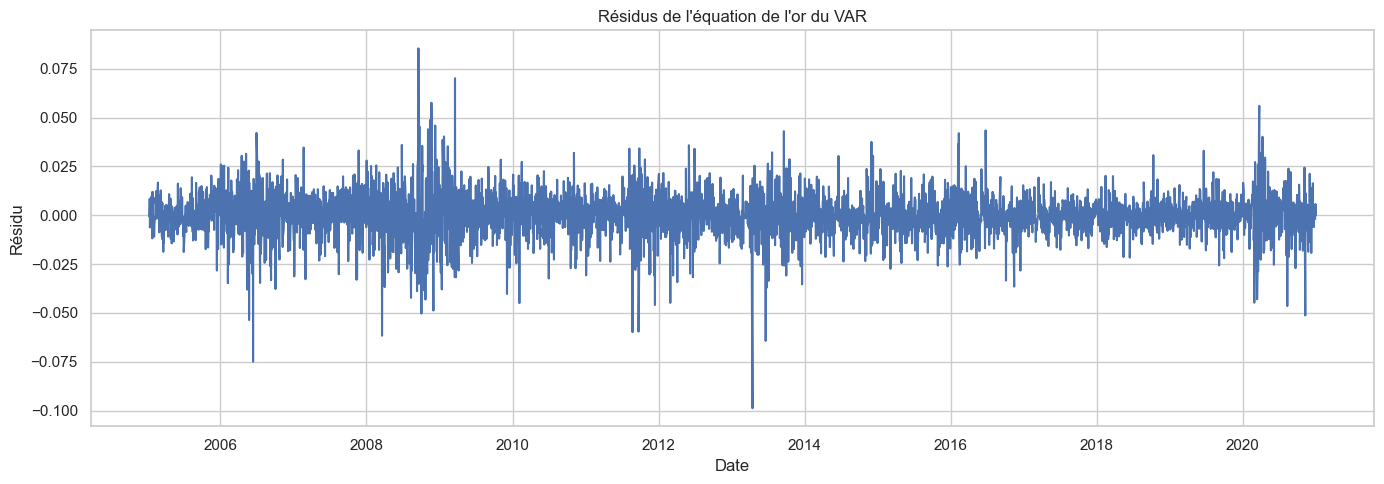

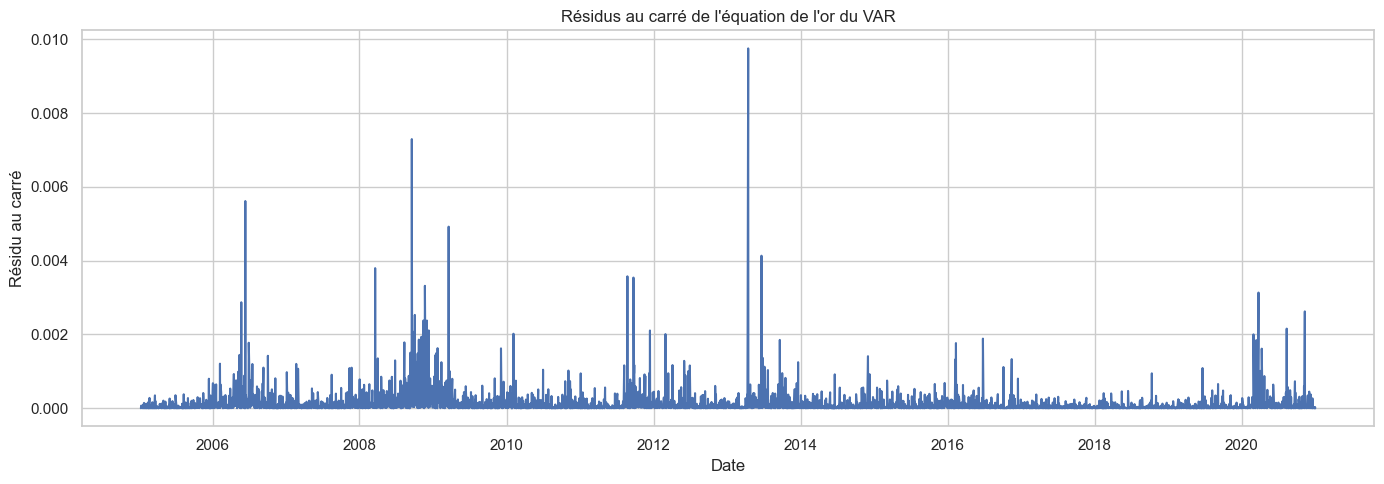

<Figure size 1000x500 with 0 Axes>

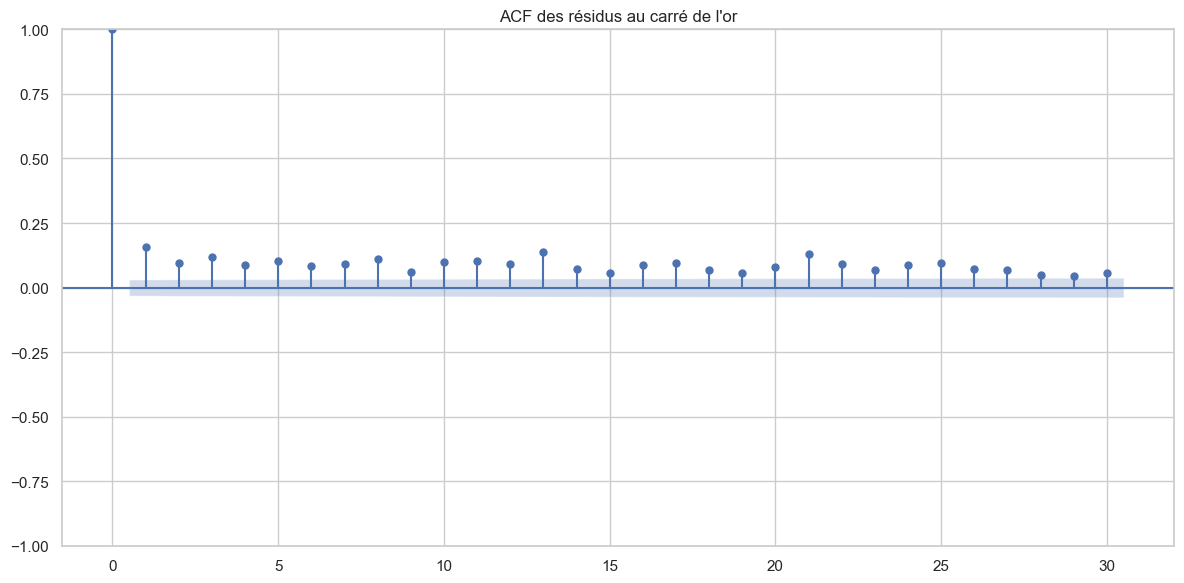

In [28]:
gold_resid_train_df = extract_gold_var_residuals(reduced_var_results["fitted_model"])
plot_gold_var_residuals(gold_resid_train_df)
plot_gold_var_squared_residuals(gold_resid_train_df)
plot_gold_var_squared_residuals_acf(gold_resid_train_df, lags=30)


Les résidus de l’équation de l’or semblent globalement **centrés autour de zéro**, ce qui suggère que le VAR capte correctement la dynamique moyenne des rendements. En revanche, leur amplitude varie fortement au cours du temps : on observe des périodes calmes alternant avec des épisodes de forte turbulence, notamment autour de **2006-2009**, **2011-2013** et **2020**.

Le graphique des **résidus au carré** met clairement en évidence des **clusters de volatilité** : les chocs extrêmes ont tendance à se regrouper dans le temps au lieu d’apparaître de façon isolée. Cette lecture est confirmée par l’**ACF des résidus au carré**, où plusieurs autocorrélations restent positives et au-dessus des bandes de confiance sur de nombreux retards.

Cela signifie que, même si le VAR modélise correctement la **moyenne conditionnelle**, il laisse subsister une **hétéroscédasticité conditionnelle** dans les résidus. Autrement dit, la variance n’est pas constante et dépend de l’histoire passée des chocs.

Cette configuration justifie l’estimation d’un **modèle GARCH** sur les résidus de l’équation de l’or afin de modéliser explicitement la dynamique de volatilité. De plus, la présence de pics extrêmes suggère que l’usage d’innovations **Student-t** peut également être pertinent pour mieux prendre en compte les queues épaisses.


In [29]:
print_arch_lm_conclusion(gold_resid_train_df, nlags=12)

Test ARCH-LM sur les résidus de l'or
------------------------------------
Nombre de lags testés : 12
LM statistic : 251.372131
LM p-value : 0.000000
F statistic : 22.279013
F p-value : 0.000000
Conclusion : on rejette l'hypothèse nulle au seuil de 5%.
Il existe un effet ARCH dans les résidus.


Les résidus de l’équation de l’or issus du VAR présentent un effet ARCH significatif. Le VAR ne suffit donc pas à décrire entièrement la dynamique de la série. Il est pertinent de compléter la modélisation de la moyenne par un modèle GARCH-X afin de capturer la variance conditionnelle résiduelle.

## Modéliastion du VAR-GARCH-X

On prépare ici les **variables macro exogènes** destinées au modèle **GARCH-X**.

D’abord, `prepare_daily_macro_exog(...)` convertit les séries mensuelles `GPR` et `CPI` en un format **journalier**, en utilisant les dates de `var_df` comme calendrier de référence. Comme ces variables ne sont observées qu’à fréquence mensuelle, on applique ensuite un **forward fill** afin que chaque jour d’un même mois hérite de la dernière valeur disponible.

Ensuite, `split_macro_exog_train_test_by_date(...)` sépare ces exogènes en deux sous-périodes :
- une période **train**
- une période **test**

Enfin, `build_garchx_train_dataset(...)` fusionne les **résidus de l’équation de l’or du VAR** avec les **exogènes macro du train**. On obtient ainsi le jeu de données utilisé pour estimer le **GARCH-X**, c’est-à-dire un modèle de volatilité conditionnelle enrichi par des variables macroéconomiques.


In [30]:
macro_exog_df = prepare_daily_macro_exog(
    data_dir="data",
    daily_calendar_df=var_df[["date"]]
)

macro_exog_df = macro_exog_df.sort_values("date").reset_index(drop=True)
macro_exog_df[["gpr_level", "cpi_mom"]] = (
    macro_exog_df[["gpr_level", "cpi_mom"]].ffill()
)



macro_train_df, macro_test_df = split_macro_exog_train_test_by_date(
    macro_exog_df=macro_exog_df,
    train_start="2005-01-01",
    train_end="2020-12-31",
    test_start="2021-01-01",
    test_end="2025-12-31"
)

garchx_train_df = build_garchx_train_dataset(
    gold_resid_train_df=gold_resid_train_df,
    macro_train_df=macro_train_df
)

On estime ici un **modèle GARCH(1,1)** sur les résidus de l’équation de l’or issus du VAR, à l’aide de la fonction `fit_garch11_student(...)`.

L’objectif est de modéliser la **volatilité conditionnelle** de ces résidus, c’est-à-dire la manière dont leur variance évolue dans le temps. Cette étape est justifiée par la présence de **volatility clustering** observée dans les résidus du VAR : même si la moyenne est correctement modélisée, la variance reste dépendante du passé.

Le modèle est estimé avec des innovations **Student-t**, ce qui permet de mieux capturer les **queues épaisses** et les épisodes de chocs extrêmes souvent présents dans les rendements financiers.

Enfin, `get_garch_model_info(garch11_student_res)` permet d’afficher un résumé des principaux paramètres estimés du modèle, afin d’interpréter la dynamique de volatilité obtenue.


In [31]:
garch11_student_res = fit_garch11_student(
    gold_resid_train_df=gold_resid_train_df
)

get_garch_model_info(garch11_student_res)

{'model_name': 'GARCH(1,1)-Student',
 'loglik': np.float64(12720.881919481293),
 'success': True,
 'optimizer_message': 'CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH',
 'omega': np.float64(4.448447252040535e-06),
 'alpha': np.float64(0.050000000520152306),
 'beta': np.float64(0.900000000403104),
 'nu': np.float64(7.999999999997256)}

On estime ici un **modèle GARCH-X(1,1)** sur les résidus de l’équation de l’or issus du VAR, à partir du DataFrame `garchx_train_df`.

Par rapport au GARCH standard, ce modèle enrichit l’équation de variance en y ajoutant des **variables macroéconomiques exogènes**, ici construites à partir de `GPR` et `CPI`. L’idée est de tester si la volatilité de l’or dépend non seulement de sa propre dynamique passée, mais aussi de l’environnement macroéconomique et géopolitique.

Comme pour le GARCH simple, l’estimation repose sur des innovations **Student-t**, afin de mieux prendre en compte les épisodes de fortes fluctuations et la présence potentielle de queues épaisses.

In [32]:
garch11x_student_res = fit_garch11x_student(
    garchx_train_df=garchx_train_df
)

get_garch_model_info(garch11x_student_res)

{'model_name': 'GARCH(1,1)-X-Student',
 'loglik': np.float64(12639.414777553862),
 'success': True,
 'optimizer_message': 'CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH',
 'omega': np.float64(9.488618873829636e-06),
 'alpha': np.float64(0.09122679369809371),
 'beta': np.float64(0.8130740099682802),
 'gamma_gpr': np.float64(0.0),
 'gamma_cpi': np.float64(0.0),
 'nu': np.float64(7.73978033293596)}

Comparaison des deux modèles

In [33]:
comparison_df = pd.DataFrame([
    get_garch_model_info(garch11_student_res),
    get_garch_model_info(garch11x_student_res)
])

comparison_df

,model_name,loglik,success,optimizer_message,omega,alpha,beta,nu,gamma_gpr,gamma_cpi
0,"GARCH(1,1)-Student",12720.881919,True,CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH,0.000004,0.050000,0.900000,8.00000,NaN,NaN
1,"GARCH(1,1)-X-Student",12639.414778,True,CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH,0.000009,0.091227,0.813074,7.73978,0.0,0.0


Les deux modèles convergent correctement, ce qui signifie que l’estimation numérique s’est déroulée sans problème. On peut donc comparer leurs paramètres et leur qualité d’ajustement.

Le **GARCH(1,1)-Student** présente une log-vraisemblance plus élevée (`12720.88`) que le **GARCH(1,1)-X-Student** (`12639.41`). À ce stade, cela suggère que le modèle simple ajuste **mieux** les résidus de l’or que la version enrichie par les variables exogènes.

Dans le modèle GARCH standard, les paramètres `alpha = 0.05` et `beta = 0.90` indiquent une **forte persistance de la volatilité** : les chocs passés et la variance passée jouent un rôle important dans l’évolution de la variance conditionnelle. La somme `alpha + beta = 0.95` confirme cette inertie, typique des séries financières.

Dans le modèle GARCH-X, la persistance reste élevée (`alpha + beta ≈ 0.904`), mais elle est légèrement plus faible que dans le modèle simple. En revanche, les coefficients associés aux variables exogènes, `gamma_gpr` et `gamma_cpi`, sont tous les deux estimés à **zéro**. Cela indique que, dans cette spécification, les variables macro introduites n’apportent pas d’information supplémentaire à la dynamique de volatilité de l’or.

Autrement dit, la volatilité semble ici être essentiellement expliquée par sa propre dynamique passée, sans gain visible lié à `GPR` ou `CPI`. Le fait que la log-vraisemblance du GARCH-X soit plus faible renforce cette conclusion : dans cette estimation, l’ajout des exogènes ne semble pas améliorer le modèle.

Enfin, les degrés de liberté `nu` sont proches dans les deux cas (`8.00` et `7.74`), ce qui confirme dans les deux modèles la présence d’innovations à **queues épaisses**, cohérentes avec le comportement habituel des rendements financiers.


## Prédiction 

On part ici des **prévisions dynamiques de rendements** produites par le VAR réduit sur la période de test. Le DataFrame `return_forecast_df` conserve uniquement la date, le rendement prédit de l’or et le rendement réellement observé.

Ensuite, `build_garch_forecast_df(...)` ajoute à ces prévisions de moyenne une **prévision de volatilité conditionnelle** issue du modèle GARCH estimé sur les résidus du VAR. On obtient ainsi, pour chaque date du test, un rendement prédit et une volatilité prédite.

La fonction `build_dynamic_price_forecast(...)` utilise ensuite ces rendements prédits pour **reconstruire dynamiquement le prix de l’or** sur la période de test, en partant du dernier prix observé avant le début du test. Comme les rendements sont des **log-rendements**, la reconstruction se fait avec l’exponentielle.

Enfin, on renomme les colonnes pour les rendre compatibles avec la fonction de visualisation, puis on trace le **prix observé** et le **prix prédit** sur la période de test.


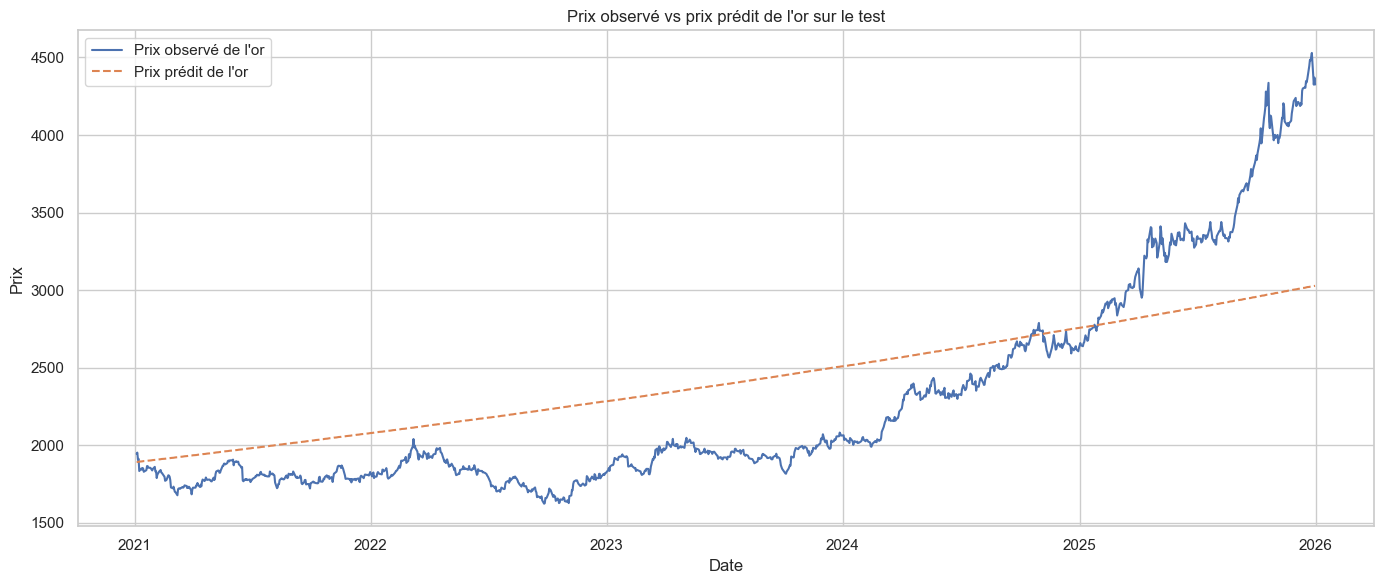

,date,gold_ret_pred,gold_ret_actual,garch_cond_vol_pred,actual_price,predicted_price
0,2021-01-04,-0.000410,0.026892,0.008548,1944.699951,1892.324177
1,2021-01-05,-0.000064,0.004105,0.008595,1952.699951,1892.202828
2,2021-01-06,0.000265,-0.023734,0.008639,1906.900024,1892.704485
3,2021-01-07,0.000643,0.002828,0.008680,1912.300049,1893.922491
4,2021-01-08,0.000339,-0.041753,0.008719,1834.099976,1894.565291
...,...,...,...,...,...,...
1250,2025-12-24,0.000375,-0.000491,0.009432,4480.600098,3023.075150
1251,2025-12-26,0.000375,0.010766,0.009432,4529.100098,3024.209078
1252,2025-12-29,0.000375,-0.046088,0.009432,4325.100098,3025.343431
1253,2025-12-30,0.000375,0.010351,0.009432,4370.100098,3026.478209


In [34]:
return_forecast_df = reduced_var_results["forecast_df_dynamic"][["date", "gold_ret_pred", "gold_ret_actual"]].copy()

garch_forecast_df = build_garch_forecast_df(
    garch_result=garch11_student_res,
    gold_resid_train_df=gold_resid_train_df,
    forecast_df=return_forecast_df,
    date_col="date",
    pred_return_col="gold_ret_pred",
    actual_return_col="gold_ret_actual"
)


garch_price_forecast_df = build_dynamic_price_forecast(
    price_df=price_df,
    forecast_df=garch_forecast_df,
    price_col="gold_price",
    pred_return_col="gold_ret_pred",
    actual_return_col="gold_ret_actual",
    pred_vol_col="garch_cond_vol_pred",
    date_col="date",
    return_type="log"
)

garch_price_plot_df = garch_price_forecast_df.rename(columns={
    "actual_price": "gold_price_actual",
    "predicted_price": "gold_price_pred"
})

plot_gold_price_actual_vs_predicted_test(garch_price_plot_df)

garch_price_forecast_df

On observe ici que, du fait de la stabilité du VAR, les rendements prédits convergent progressivement vers une valeur quasi constante. À horizon lointain, la trajectoire prévue perd donc en variabilité et devient peu informative, ce qui rend la prédiction de plus en plus obsolète.

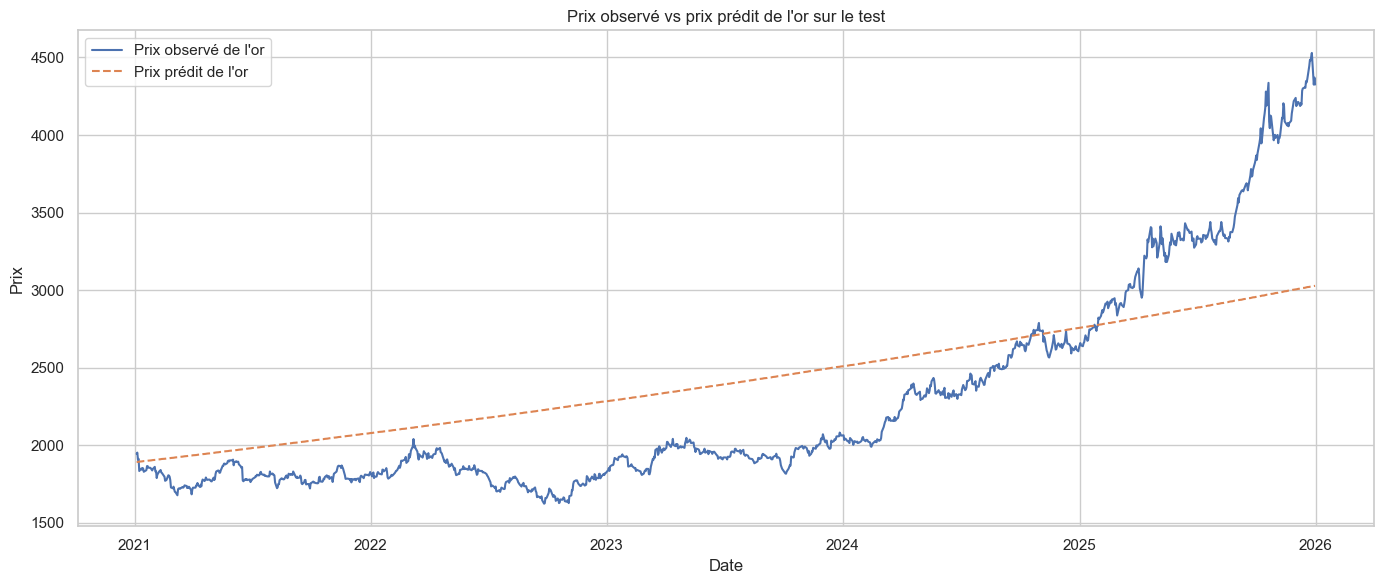

In [35]:
return_forecast_df = reduced_var_results["forecast_df_dynamic"][["date", "gold_ret_pred", "gold_ret_actual"]].copy()

garchx_forecast_df = build_garchx_forecast_df(
    garchx_result=garch11x_student_res,
    gold_resid_train_df=gold_resid_train_df,
    macro_train_df=macro_train_df,
    macro_test_df=macro_test_df,
    forecast_df=return_forecast_df,
    date_col="date",
    pred_return_col="gold_ret_pred",
    actual_return_col="gold_ret_actual"
)

garchx_forecast_df.head()


garchx_price_forecast_df = build_dynamic_price_forecast(
    price_df=price_df,
    forecast_df=garchx_forecast_df,
    price_col="gold_price",
    pred_return_col="gold_ret_pred",
    actual_return_col="gold_ret_actual",
    pred_vol_col="garch_cond_vol_pred",
    date_col="date",
    return_type="log"
)

garchx_price_plot_df = garchx_price_forecast_df.rename(columns={
    "actual_price": "gold_price_actual",
    "predicted_price": "gold_price_pred"
})

plot_gold_price_actual_vs_predicted_test(garchx_price_plot_df)

De même qu'ici, ce qui justifie de rendre alétoire la distribution donné par le GARCH 

## Monte-Carlo pour le VAR-GARCH-X 

On récupère d’abord le paramètre `nu` du modèle **GARCH-X Student**, car il sert à simuler les innovations aléatoires de la loi de Student dans l’étape Monte Carlo.

La fonction `run_var_garchx_monte_carlo_pipeline(...)` exécute ensuite tout le pipeline de simulation :
- elle combine la **moyenne prédite** par le VAR (`gold_ret_pred`) ;
- avec la **volatilité prédite** par le GARCH-X (`garch_cond_vol_pred`) ;
- puis génère plusieurs trajectoires simulées de rendements et de prix sur la période de test.

Les objets extraits ensuite correspondent aux principales sorties du pipeline :
- `simulation_input_df` : données d’entrée de la simulation ;
- `simulated_returns_matrix` : matrice des rendements simulés ;
- `simulated_returns_summary_df` : résumé statistique des rendements simulés ;
- `simulated_price_matrix` : matrice des prix simulés ;
- `simulated_price_summary_df` : résumé statistique des prix simulés.

Enfin, les `display(...)` et `print(...)` permettent de vérifier que la simulation a bien fonctionné :
- en regardant la structure des DataFrames produits ;
- en contrôlant les dimensions des matrices simulées ;
- et en vérifiant la période effectivement couverte par la simulation.


In [36]:
nu_garchx = garch11x_student_res["params"]["nu"]

mc_garchx_results = run_var_garchx_monte_carlo_pipeline(
    price_df=price_df,
    return_forecast_df=return_forecast_df,
    vol_forecast_df=garchx_forecast_df,
    nu=nu_garchx,
    n_simulations=1000,
    random_state=42
)

simulation_input_df = mc_garchx_results["simulation_input_df"]
simulated_returns_matrix = mc_garchx_results["simulated_returns_matrix"]
simulated_returns_summary_df = mc_garchx_results["simulated_returns_summary_df"]
simulated_price_matrix = mc_garchx_results["simulated_price_matrix"]
simulated_price_summary_df = mc_garchx_results["simulated_price_summary_df"]

display(simulation_input_df.head())
display(garchx_forecast_df.head())
display(simulated_returns_summary_df.head())
display(simulated_price_summary_df.head())

print("Colonnes simulation_input_df :", simulation_input_df.columns.tolist())
print("Colonnes simulated_returns_summary_df :", simulated_returns_summary_df.columns.tolist())
print("Colonnes simulated_price_summary_df :", simulated_price_summary_df.columns.tolist())

print("Dimensions simulated_returns_matrix :", simulated_returns_matrix.shape)
print("Dimensions simulated_price_matrix :", simulated_price_matrix.shape)

print("Periode simulation :", simulated_price_summary_df["date"].min(), "->", simulated_price_summary_df["date"].max())

,date,gold_ret_pred,garch_cond_vol_pred,gold_ret_actual
0,2021-01-04,-0.000410,0.008032,0.026892
1,2021-01-05,-0.000064,0.008235,0.004105
2,2021-01-06,0.000265,0.008415,-0.023734
3,2021-01-07,0.000643,0.008575,0.002828
4,2021-01-08,0.000339,0.008717,-0.041753


,date,gold_ret_pred,gold_ret_actual,gpr_level,cpi_mom,garch_cond_var_pred,garch_cond_vol_pred
0,2021-01-04,-0.000410,0.026892,77.418701,0.00245,0.000065,0.008032
1,2021-01-05,-0.000064,0.004105,77.418701,0.00245,0.000068,0.008235
2,2021-01-06,0.000265,-0.023734,77.418701,0.00245,0.000071,0.008415
3,2021-01-07,0.000643,0.002828,77.418701,0.00245,0.000074,0.008575
4,2021-01-08,0.000339,-0.041753,77.418701,0.00245,0.000076,0.008717


,date,gold_ret_pred,garch_cond_vol_pred,gold_ret_actual,gold_ret_sim_mean,gold_ret_sim_median,gold_ret_sim_q05,gold_ret_sim_q95
0,2021-01-04,-0.000410,0.008032,0.026892,-0.000810,-0.000637,-0.013966,0.012241
1,2021-01-05,-0.000064,0.008235,0.004105,-0.000116,-0.000001,-0.013586,0.012039
2,2021-01-06,0.000265,0.008415,-0.023734,0.000416,-0.000015,-0.012993,0.014218
3,2021-01-07,0.000643,0.008575,0.002828,0.000223,0.000294,-0.014022,0.013807
4,2021-01-08,0.000339,0.008717,-0.041753,-0.000017,-0.000125,-0.013838,0.013560


,date,gold_price_actual,gold_price_sim_mean,gold_price_sim_median,gold_price_sim_q05,gold_price_sim_q95
0,2021-01-04,1944.699951,1891.628946,1891.894587,1866.845152,1916.415640
1,2021-01-05,1952.699951,1891.471448,1891.903402,1855.705336,1926.036754
2,2021-01-06,1906.900024,1892.320417,1891.962800,1848.193774,1935.207054
3,2021-01-07,1912.300049,1892.815391,1892.410287,1841.520747,1942.711792
4,2021-01-08,1834.099976,1892.856652,1893.702040,1832.625949,1950.759599


Colonnes simulation_input_df : ['date', 'gold_ret_pred', 'garch_cond_vol_pred', 'gold_ret_actual']
Colonnes simulated_returns_summary_df : ['date', 'gold_ret_pred', 'garch_cond_vol_pred', 'gold_ret_actual', 'gold_ret_sim_mean', 'gold_ret_sim_median', 'gold_ret_sim_q05', 'gold_ret_sim_q95']
Colonnes simulated_price_summary_df : ['date', 'gold_price_actual', 'gold_price_sim_mean', 'gold_price_sim_median', 'gold_price_sim_q05', 'gold_price_sim_q95']
Dimensions simulated_returns_matrix : (1255, 1000)
Dimensions simulated_price_matrix : (1255, 1000)
Periode simulation : 2021-01-04 00:00:00 -> 2025-12-31 00:00:00


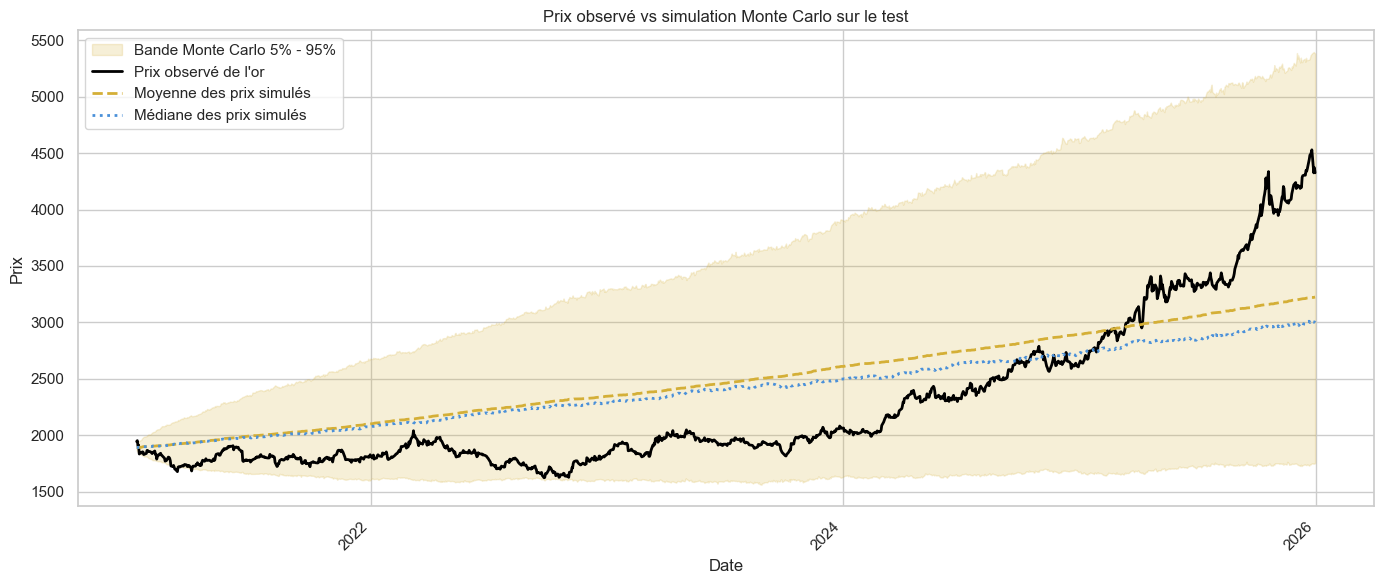

In [37]:
plot_gold_price_monte_carlo_test(
    simulated_price_summary_df=simulated_price_summary_df,
    figsize=(14, 6),
    show_median=True,
    show_band=True
)

Le graphique montre que les trajectoires prédites, qu’il s’agisse de la moyenne ou de la médiane des prix simulés, suivent une évolution très régulière, proche d’une **droite croissante**. Elles ne reproduisent donc pas les fluctuations effectives du prix observé, qui reste beaucoup plus irrégulier et marqué par des changements de régime.

Cela signifie que les prévisions obtenues ici ne sont **pas satisfaisantes** : à mesure que l’horizon s’allonge, elles deviennent trop lisses, trop mécaniques, et finissent par perdre leur pouvoir informatif. En pratique, elles deviennent donc **rapidement obsolètes**.

Cette limite provient principalement du fait que le **VAR est stable**. Dans un VAR stable, les rendements prévus convergent progressivement vers leur moyenne inconditionnelle. Dès lors, même si l’on ajoute ensuite de la volatilité via le GARCH ou de l’incertitude via Monte Carlo, la dynamique de moyenne finit par se tasser et impose une trajectoire trop régulière aux prix simulés.

Autrement dit :
- le modèle génère bien de l’incertitude ;
- mais la structure centrale de la prévision reste dominée par une dynamique moyenne trop stable ;
- ce qui explique pourquoi les prédictions finissent par ressembler à une droite plutôt qu’à une trajectoire réaliste du prix de l’or.


# VAR-GARCH avec simulation stochastique 

Ce pipeline parallèle prévoit le prix de l’or en combinant :

- un **VAR réduit** sur `gold_ret`, `dxy_ret` et `vix_ret` pour modéliser la moyenne ;
- un **GARCH(1,1)** sur les résidus de l’équation de l’or pour modéliser la volatilité ( On à choisi de pas prendre de variable exogène car leurs coefficients étaient nuls); 
- une **simulation Monte Carlo** pour générer des trajectoires futures possibles.

Le fonctionnement est le suivant :

1. on découpe les données en **train** et **test** ;
2. on choisit le **lag optimal** du VAR sur le train ;
3. on estime le **VAR réduit** ;
4. on extrait les **résidus de l’or** ;
5. on estime un **GARCH(1,1)** sur ces résidus ;
6. on simule sur le test des rendements futurs à partir :
   - de la moyenne conditionnelle du VAR,
   - de la volatilité conditionnelle du GARCH,
   - d’un bruit aléatoire ;
7. on reconstruit ensuite les **prix simulés** de l’or ;
8. on compare enfin le **prix observé** et le **prix prédit**.

L’intérêt de cette approche est qu’elle ne produit pas seulement une prévision ponctuelle : elle permet aussi de représenter l’**incertitude** autour de la trajectoire future du prix de l’or.


,date,gold_price_actual,gold_price_pred
0,2022-01-03,1799.400024,1834.039242
1,2022-01-04,1814.000000,1817.998522
2,2022-01-05,1824.599976,1783.996132
3,2022-01-06,1788.699951,1789.137158
4,2022-01-07,1797.000000,1802.671767


,date,gold_price_actual,gold_price_sim_mean,gold_price_sim_median,gold_price_sim_q05,gold_price_sim_q95
0,2022-01-03,1799.400024,1828.326907,1828.211355,1804.811802,1851.397003
1,2022-01-04,1814.000000,1829.313932,1829.155014,1795.912064,1862.810018
2,2022-01-05,1824.599976,1829.614411,1829.580579,1787.597399,1870.847538
3,2022-01-06,1788.699951,1829.551061,1829.666468,1782.315815,1876.795426
4,2022-01-07,1797.000000,1830.034280,1830.333165,1777.001545,1883.214069


,date,gold_ret_pred,garch_cond_vol_pred,gold_ret_actual,gold_ret_sim_mean,gold_ret_sim_median,gold_ret_sim_q05,gold_ret_sim_q95
0,2022-01-03,0.000624,0.007926,-0.015496,0.000421,0.000389,-0.012493,0.012992
1,2022-01-04,0.000253,0.008006,0.008081,0.000508,0.000456,-0.012517,0.013927
2,2022-01-05,0.000295,0.008082,0.005826,0.000132,0.000086,-0.013045,0.013323
3,2022-01-06,0.000093,0.008153,-0.019872,-0.000065,-0.000029,-0.013333,0.013326
4,2022-01-07,0.000307,0.008221,0.004630,0.000231,0.000147,-0.012915,0.013236


Lag final retenu : 4
Paramètres GARCH : {'omega': np.float64(4.423249675261822e-06), 'alpha': np.float64(0.05000000042692851), 'beta': np.float64(0.9000000003634756), 'nu': np.float64(7.9999999999970015)}
Index de la trajectoire retenue : 0
Dimensions simulated_returns_matrix : (1077, 5000)
Dimensions simulated_price_matrix : (1077, 5000)


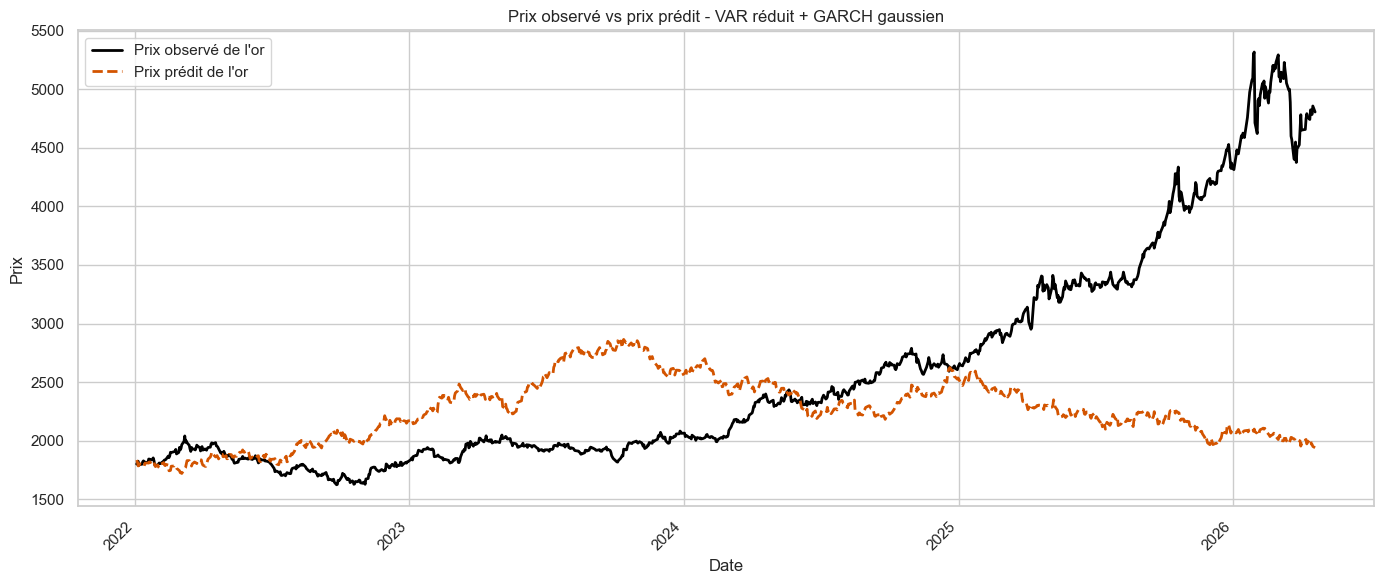

In [42]:
import importlib
import reduced_var_garch_monte_carlo as rgmc
import monte_carlo_vis as mcvis

importlib.reload(rgmc)
importlib.reload(mcvis)

results = rgmc.run_reduced_var_garch_monte_carlo_pipeline(
    data_dir="data",
    train_start="2005-01-01",
    train_end="2021-12-31",
    test_start="2022-01-01",
    test_end="2026-12-31",
    window_years=7,
    step_years=2,
    max_lag=10,
    n_simulations=5000,
    random_state=42,
    prediction_mode="single_path",
    selected_path_index=0
)

predicted_price_df = results["predicted_price_df"]
simulated_price_summary_df = results["simulated_price_summary_df"]
simulated_returns_summary_df = results["simulated_returns_summary_df"]

display(predicted_price_df.head())
display(simulated_price_summary_df.head())
display(simulated_returns_summary_df.head())

print("Lag final retenu :", results["final_lag"])
print("Paramètres GARCH :", results["garch_result"]["params"])
print("Index de la trajectoire retenue :", results["selected_simulation_index"])
print("Dimensions simulated_returns_matrix :", results["simulated_returns_matrix"].shape)
print("Dimensions simulated_price_matrix :", results["simulated_price_matrix"].shape)

mcvis.plot_gold_price_reduced_var_garch_prediction_test(
    predicted_price_df=predicted_price_df,
    figsize=(14, 6),
    major="year",
    date_format="%Y"
)


Ici, la prévision est nettement plus réaliste que dans le cas précédent : la trajectoire prédite n’est plus une simple droite, mais une **vraie trajectoire stochastique**, avec des variations visibles au cours du temps. Le modèle parvient donc à mieux restituer la **volatilité de court terme**, en particulier au début de la période de test, lorsque la tendance haussière du prix de l’or reste encore modérée.

Dans cette première phase, la prédiction reste relativement cohérente avec les mouvements observés : elle capte mieux les fluctuations locales et reproduit une dynamique plus crédible que la moyenne Monte Carlo lissée.

En revanche, à partir du moment où la tendance haussière du prix de l’or devient beaucoup plus marquée, le modèle peine à suivre. La trajectoire prédite reste en dessous du prix observé et ne parvient pas à reproduire l’accélération du mouvement haussier. Autrement dit, la prévision reste pertinente à court horizon ou dans des phases de marché plus stables, mais elle devient plus difficile à soutenir lorsque le marché entre dans une dynamique fortement directionnelle.

Cela confirme que cette approche améliore la représentation de la **volatilité** et de la **variabilité locale**, mais qu’elle reste limitée pour capter des changements de régime ou des tendances haussières très fortes sur un horizon long.
